# Fixed G12 vs Free G12 Fit: Impact on SSObject Photometric Parameters

This notebook compares the SSObject table outputs from two runs of `ConsolidateSsTablesTask`:

- **test_0** (before): Free G12 fit — both H (absolute magnitude) and G12 (slope parameter) are fit simultaneously
- **test_3** (after): Fixed G12=0.5 — only H is fit, G12 is held fixed at 0.5

The HG12 model (Muinonen et al. 2010) relates an asteroid's apparent magnitude to its phase angle via two parameters: H (absolute magnitude) and G12 (slope). When phase angle coverage is sparse, fitting both parameters simultaneously is poorly constrained, leading to unphysical G12 values, unreliable H estimates, and inflated uncertainties.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({'font.size': 12, 'figure.facecolor': 'white'})

BANDS = list('ugrizy')
BAND_COLORS = {'u': '#56b4e9', 'g': '#009e73', 'r': '#e69f00', 'i': '#cc79a7', 'z': '#d55e00', 'y': '#0072b2'}

df0 = pd.read_parquet('../test_0.parquet')  # before: free G12
df3 = pd.read_parquet('../test_3.parquet')  # after: fixed G12=0.5

assert (df0['ssObjectId'] == df3['ssObjectId']).all(), 'Object IDs differ!'
print(f'Loaded {len(df0):,} objects')

Loaded 299,819 objects


## 1. Fit Success Rates

With the free fit, the 2-parameter least-squares solver frequently fails — especially for objects with few observations or limited phase angle coverage. Fixing G12 reduces the problem to a single parameter (H), making the fit far more robust.

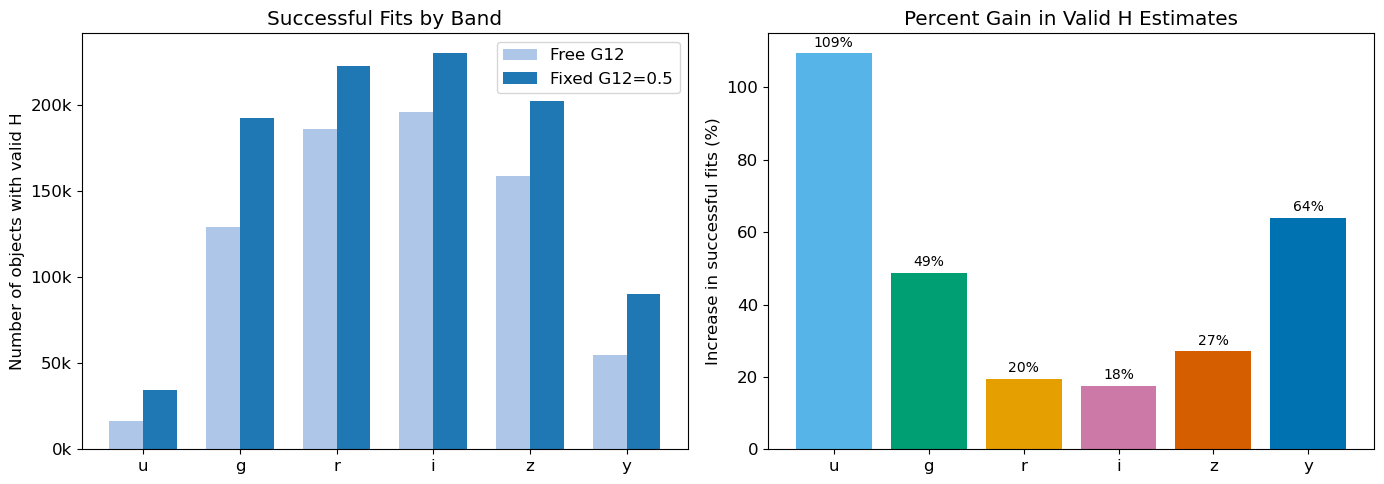

 Band     Before      After     Gained   Gain %   Failed before   Failed after
    u     16,535     34,637    +18,102     109%          18,791            689
    g    129,383    192,419    +63,036      49%          67,666          4,630
    r    186,362    222,814    +36,452      20%          38,864          2,412
    i    195,935    230,351    +34,416      18%          36,138          1,722
    z    159,174    202,267    +43,093      27%          44,371          1,278
    y     55,108     90,356    +35,248      64%          35,734            486


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fit success counts
before_valid = [df0[f'{b}_H'].notna().sum() for b in BANDS]
after_valid = [df3[f'{b}_H'].notna().sum() for b in BANDS]
before_failed = [df0[f'{b}_slope_fit_failed'].sum() for b in BANDS]
after_failed = [df3[f'{b}_slope_fit_failed'].sum() for b in BANDS]

x = np.arange(len(BANDS))
w = 0.35
ax = axes[0]
ax.bar(x - w/2, before_valid, w, label='Free G12', color='#aec7e8')
ax.bar(x + w/2, after_valid, w, label='Fixed G12=0.5', color='#1f77b4')
ax.set_xticks(x)
ax.set_xticklabels(BANDS)
ax.set_ylabel('Number of objects with valid H')
ax.set_title('Successful Fits by Band')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Percent gain
ax = axes[1]
gain_pct = [(a - b) / b * 100 if b > 0 else 0 for a, b in zip(after_valid, before_valid)]
bars = ax.bar(x, gain_pct, color=[BAND_COLORS[b] for b in BANDS])
ax.set_xticks(x)
ax.set_xticklabels(BANDS)
ax.set_ylabel('Increase in successful fits (%)')
ax.set_title('Percent Gain in Valid H Estimates')
for bar, pct in zip(bars, gain_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.0f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Band":>5} {"Before":>10} {"After":>10} {"Gained":>10} {"Gain %":>8} {"Failed before":>15} {"Failed after":>14}')
for i, b in enumerate(BANDS):
    gained = after_valid[i] - before_valid[i]
    print(f'{b:>5} {before_valid[i]:>10,} {after_valid[i]:>10,} {gained:>+10,} {gain_pct[i]:>7.0f}% {before_failed[i]:>15,} {after_failed[i]:>14,}')

The fixed G12 fit dramatically increases the number of successful fits across all bands:
- **u-band** sees the largest relative gain (+109%), going from ~16k to ~35k valid H values
- **y-band** gains 64%, and the remaining bands gain 18-49%
- **Zero fits are lost** — every object that had a valid H before still has one after
- Fit failures drop from tens of thousands to hundreds or low thousands per band

The newly gained fits are predominantly low-observation objects (median 3-4 observations) where the 2-parameter fit was failing.

## 2. Free-Fit G12 Values Were Largely Unphysical

The G12 parameter should be in a physically meaningful range (roughly 0 to 1). The free fit produced wildly unphysical values for a large fraction of objects.

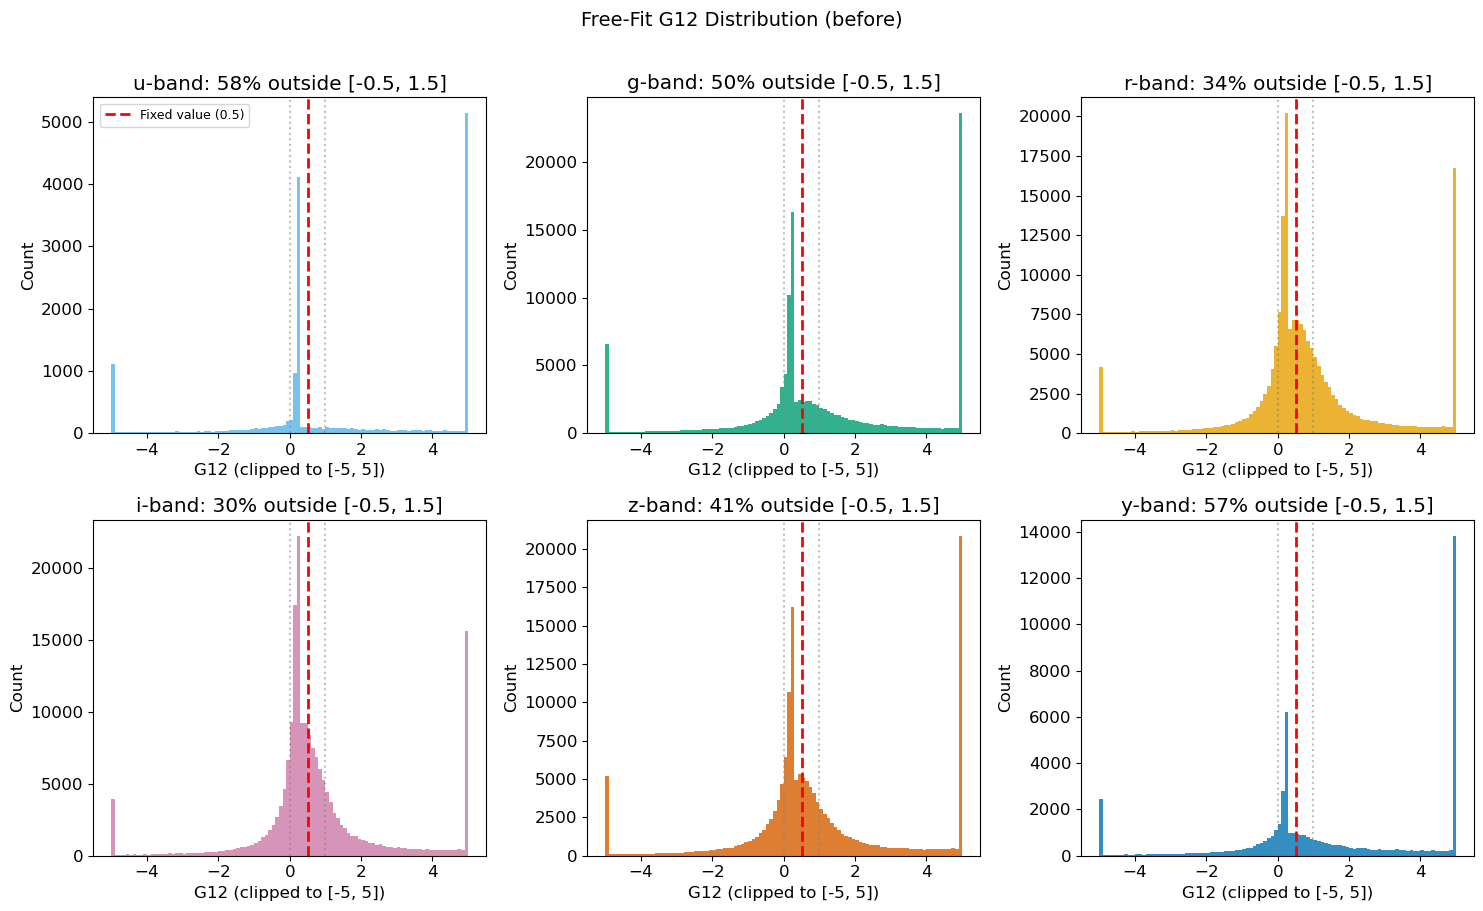

Fraction of free-fit G12 values outside [-0.5, 1.5]:
  u: 9,570/16,535 (57.9%)
  g: 64,361/129,383 (49.7%)
  r: 63,323/186,362 (34.0%)
  i: 59,028/195,935 (30.1%)
  z: 65,814/159,174 (41.3%)
  y: 31,644/55,108 (57.4%)


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    g12 = df0[f'{b}_G12'].dropna()
    
    # Clip for histogram display
    clipped = g12.clip(-5, 5)
    ax.hist(clipped, bins=100, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Fixed value (0.5)')
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(1, color='gray', linestyle=':', alpha=0.5)
    
    outside = ((g12 < -0.5) | (g12 > 1.5)).sum()
    pct = outside / len(g12) * 100
    ax.set_title(f'{b}-band: {pct:.0f}% outside [-0.5, 1.5]')
    ax.set_xlabel('G12 (clipped to [-5, 5])')
    ax.set_ylabel('Count')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Free-Fit G12 Distribution (before)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Fraction of free-fit G12 values outside [-0.5, 1.5]:')
for b in BANDS:
    g12 = df0[f'{b}_G12'].dropna()
    outside = ((g12 < -0.5) | (g12 > 1.5)).sum()
    print(f'  {b}: {outside:,}/{len(g12):,} ({outside/len(g12)*100:.1f}%)')

**30-58% of free-fit G12 values are outside the physically meaningful range** [-0.5, 1.5], with extreme values reaching into the millions. The worst-affected bands (u, y) are those with the fewest observations per object. This confirms the free fit is poorly constrained for a large fraction of the dataset and fixing G12=0.5 is a reasonable choice.

## 3. Impact on H (Absolute Magnitude)

For objects where both fits succeeded, how much does the H estimate change?

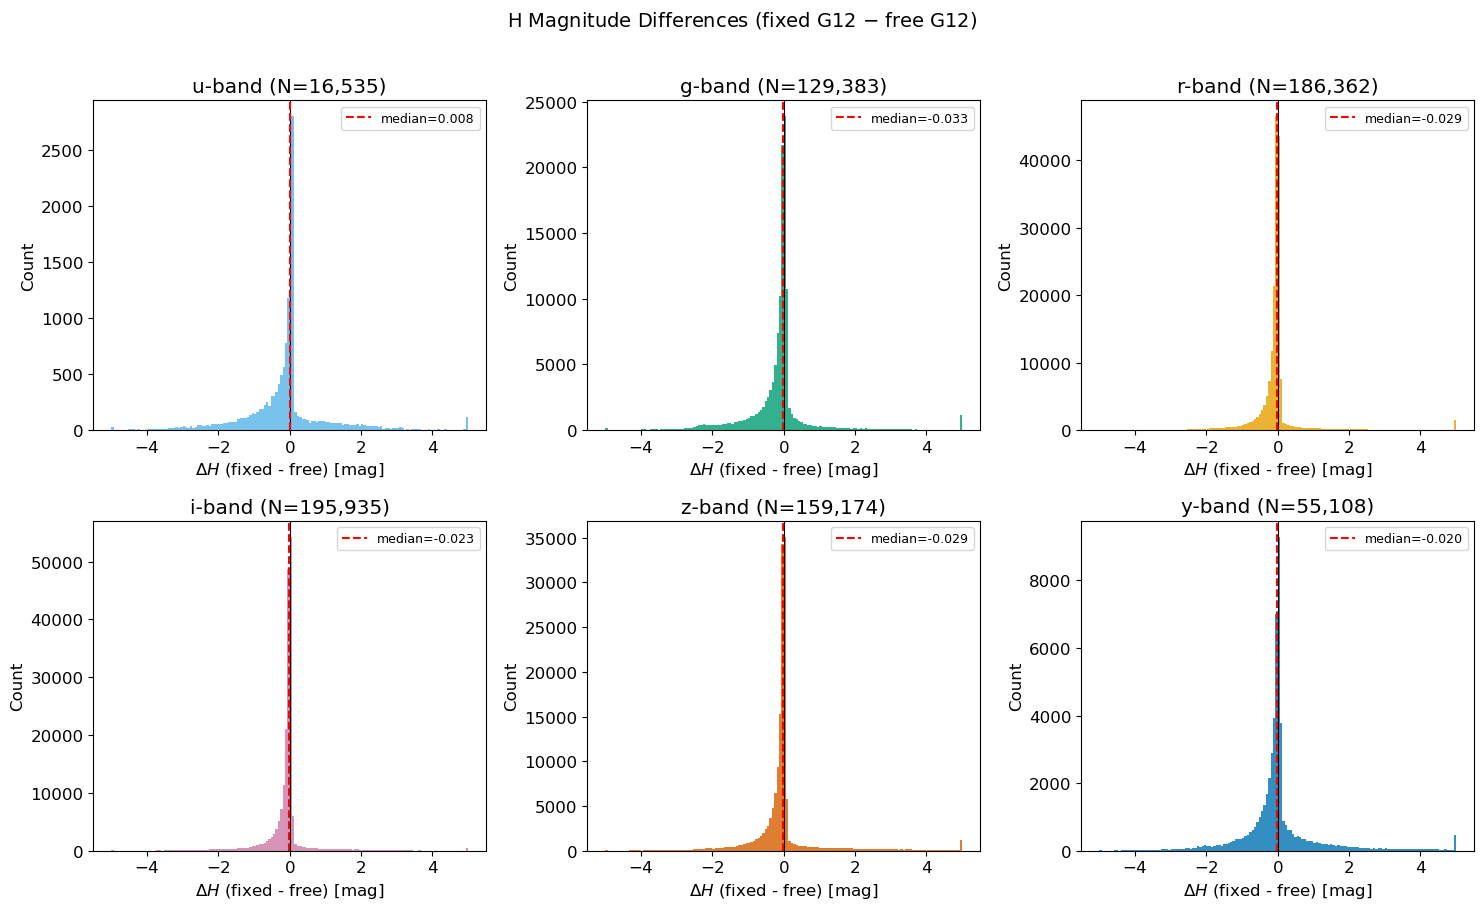

 Band       N     Mean   Median      Std      Min      Max
    u  16,535  -0.0954  +0.0081   1.2557   -14.14   +10.54
    g 129,383  -0.1109  -0.0335   1.1730   -12.26   +12.98
    r 186,362  -0.0168  -0.0291   0.9507   -13.20   +14.34
    i 195,935  -0.0700  -0.0228   0.7268    -7.04   +15.43
    z 159,174  +0.0074  -0.0289   1.0707   -12.99   +14.40
    y  55,108  +0.0407  -0.0202   1.1935    -6.68   +12.58


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    h0 = df0[f'{b}_H']
    h3 = df3[f'{b}_H']
    mask = h0.notna() & h3.notna()
    diff = h3[mask] - h0[mask]
    
    clipped = diff.clip(-5, 5)
    ax.hist(clipped, bins=150, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(diff.median(), color='red', linestyle='--', linewidth=1.5, label=f'median={diff.median():.3f}')
    ax.set_title(f'{b}-band (N={mask.sum():,})')
    ax.set_xlabel('$\\Delta H$ (fixed - free) [mag]')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('H Magnitude Differences (fixed G12 $-$ free G12)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'{"Band":>5} {"N":>7} {"Mean":>8} {"Median":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
for b in BANDS:
    h0 = df0[f'{b}_H']
    h3 = df3[f'{b}_H']
    mask = h0.notna() & h3.notna()
    diff = h3[mask] - h0[mask]
    print(f'{b:>5} {len(diff):>7,} {diff.mean():>+8.4f} {diff.median():>+8.4f} {diff.std():>8.4f} {diff.min():>+8.2f} {diff.max():>+8.2f}')

/tmp/ipykernel_119760/3532608416.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_used, showfliers=False, patch_artist=True)
/tmp/ipykernel_119760/3532608416.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_used, showfliers=False, patch_artist=True)


/tmp/ipykernel_119760/3532608416.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_used, showfliers=False, patch_artist=True)
/tmp/ipykernel_119760/3532608416.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_used, showfliers=False, patch_artist=True)
/tmp/ipykernel_119760/3532608416.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_used, showfliers=False, patch_artist=True)
/tmp/ipykernel_119760/3532608416.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_l

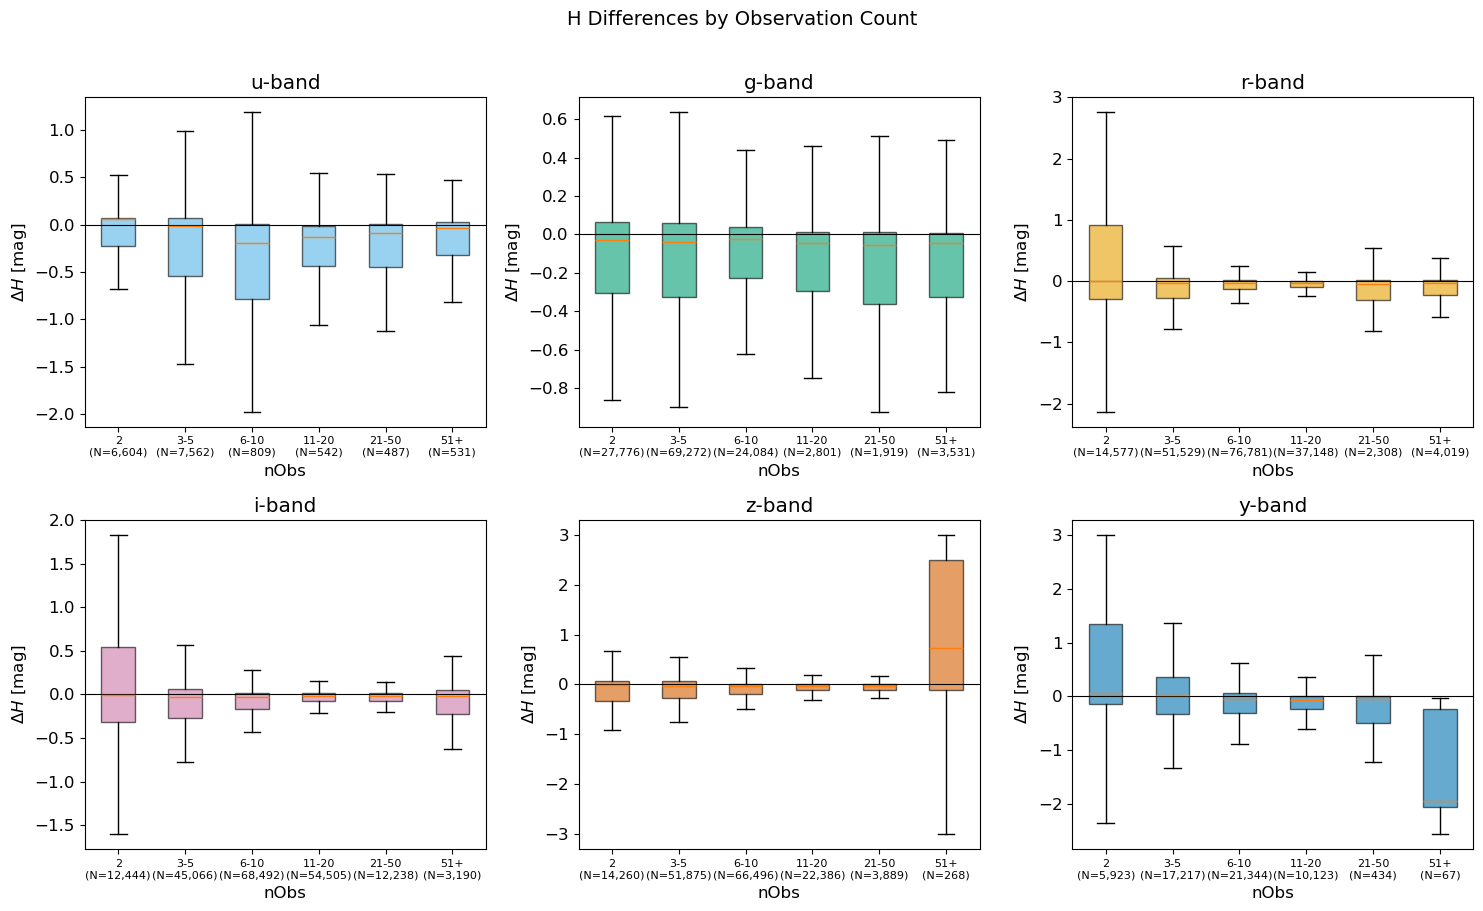

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

nobs_bins = [(2, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, 1000)]
nobs_labels = ['2', '3-5', '6-10', '11-20', '21-50', '51+']

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    h0 = df0[f'{b}_H']
    h3 = df3[f'{b}_H']
    nobs = df0[f'{b}_nObs']
    mask = h0.notna() & h3.notna()
    diff = h3[mask] - h0[mask]
    nobs_m = nobs[mask]
    
    data = []
    labels_used = []
    for (lo, hi), lbl in zip(nobs_bins, nobs_labels):
        sel = (nobs_m >= lo) & (nobs_m <= hi)
        d = diff[sel]
        if len(d) > 5:
            data.append(d.clip(-3, 3).values)
            labels_used.append(f'{lbl}\n(N={len(d):,})')
    
    if data:
        bp = ax.boxplot(data, labels=labels_used, showfliers=False, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor(BAND_COLORS[b])
            patch.set_alpha(0.6)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title(f'{b}-band')
    ax.set_xlabel('nObs')
    ax.set_ylabel('$\\Delta H$ [mag]')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('H Differences by Observation Count', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Median H shifts are small** (typically -0.04 to +0.01 mag), indicating the fixed G12 is not introducing a systematic bias for the bulk of the population.

However, the scatter is substantial at low nObs:
- For **nObs=2**, the std of the difference is ~2 mag — these are objects where the free fit was essentially unconstrained (fitting 2 parameters with 2 data points, i.e., 0 degrees of freedom)
- For **nObs 6-10**, the std drops to ~0.5 mag
- For **nObs > 20**, differences are small and well-behaved

About 9.5% of r-band objects show |delta H| > 1 mag, but these are overwhelmingly low-nObs objects where the free fit was unreliable.

## 4. Impact on H Errors

The uncertainty on H from the covariance matrix should reflect our actual knowledge. With the free fit, poorly constrained G12 inflates the H uncertainty through the covariance.

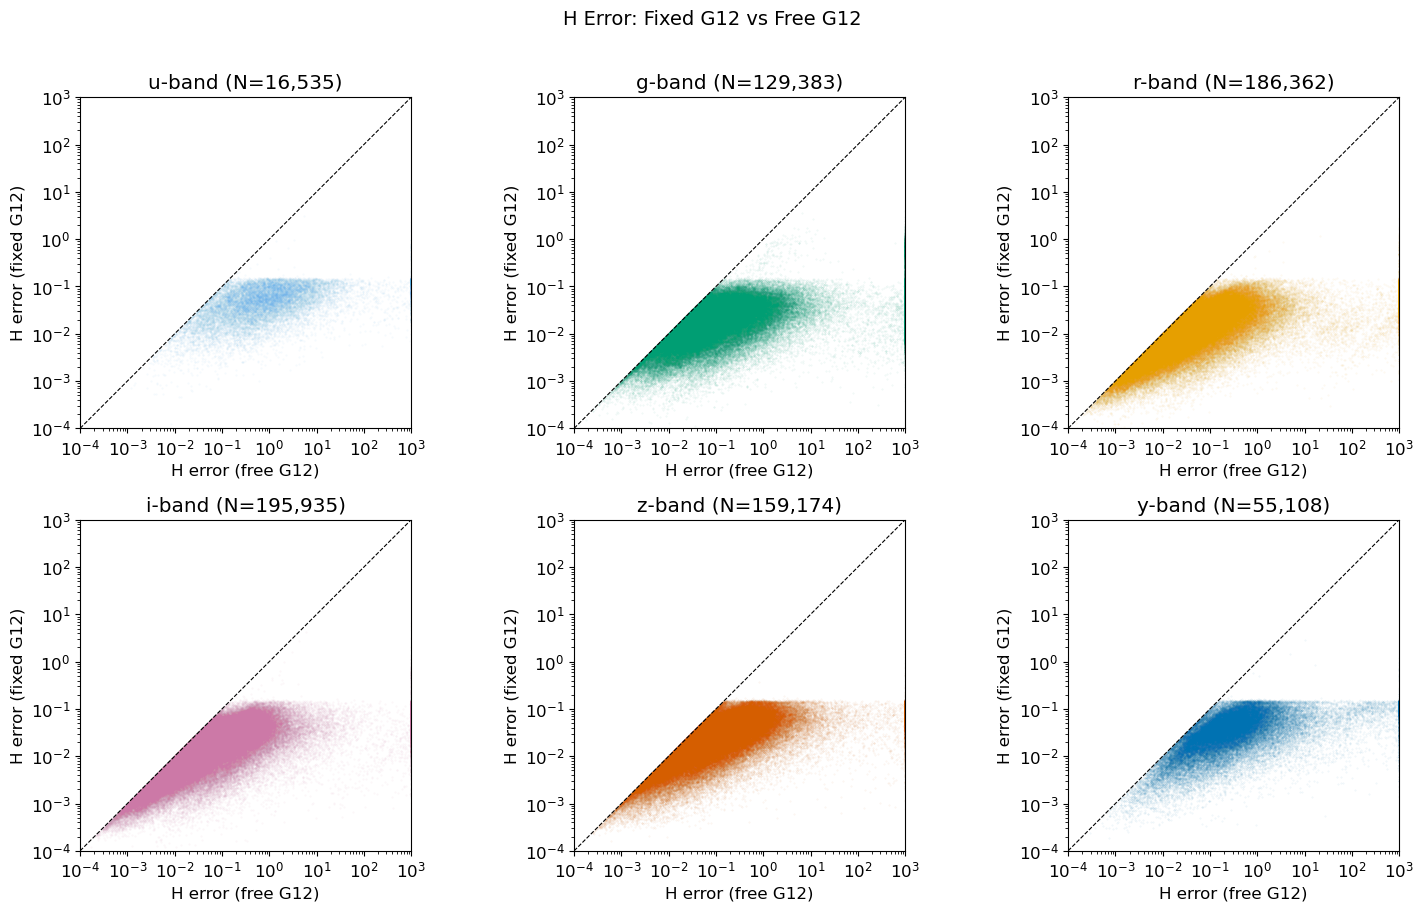

 Band       N    Mean before   Mean after  Median before  Median after
    u  16,535      4630439.5       0.0580         0.7297        0.0476
    g 129,383     18953734.0       0.0313         0.1010        0.0184
    r 186,362     31554262.0       0.0186         0.0388        0.0126
    i 195,935     37085416.0       0.0208         0.0423        0.0138
    z 159,174     18692998.0       0.0328         0.0902        0.0244


    y  55,108     11149461.0       0.0433         0.2429        0.0333


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    he0 = df0[f'{b}_HErr']
    he3 = df3[f'{b}_HErr']
    mask = he0.notna() & he3.notna()
    
    # Log-scale scatter
    x = he0[mask].clip(1e-4, 1e3)
    y = he3[mask].clip(1e-4, 1e3)
    ax.scatter(x, y, s=0.1, alpha=0.1, color=BAND_COLORS[b], rasterized=True)
    lims = [1e-4, 1e3]
    ax.plot(lims, lims, 'k--', linewidth=0.8, label='1:1')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('H error (free G12)')
    ax.set_ylabel('H error (fixed G12)')
    ax.set_title(f'{b}-band (N={mask.sum():,})')
    ax.set_aspect('equal')

fig.suptitle('H Error: Fixed G12 vs Free G12', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'{"Band":>5} {"N":>7} {"Mean before":>14} {"Mean after":>12} {"Median before":>14} {"Median after":>13}')
for b in BANDS:
    he0 = df0[f'{b}_HErr']
    he3 = df3[f'{b}_HErr']
    mask = he0.notna() & he3.notna()
    print(f'{b:>5} {mask.sum():>7,} {he0[mask].mean():>14.1f} {he3[mask].mean():>12.4f} {he0[mask].median():>14.4f} {he3[mask].median():>13.4f}')

The H errors from the free fit are **catastrophically inflated** — mean values of ~10^7 in some bands, driven by the poorly constrained G12 covariance matrix. With fixed G12:

- **Mean H errors** drop from millions to 0.02-0.06 mag
- **Median H errors** decrease by 3-15x (e.g., r-band: 0.039 → 0.013)
- The scatter plot shows the vast majority of points lie below the 1:1 line: the fixed-G12 errors are almost always smaller

This makes the error estimates actually *usable* for downstream science.

## 5. Chi-Squared Behavior

The Chi2 column stores the **total** chi-squared (sum of squared residuals divided by measurement errors squared). The reduced chi-squared is chi2/nDof, where nDof = nObsUsed - nParams (2 for free fit, 1 for fixed fit).

We expect the reduced chi2 to increase slightly with fixed G12, since we're fitting fewer parameters. Very large reduced chi2 values indicate the model is a poor fit — likely due to underestimated measurement errors or intrinsic variability (e.g., rotation curves).

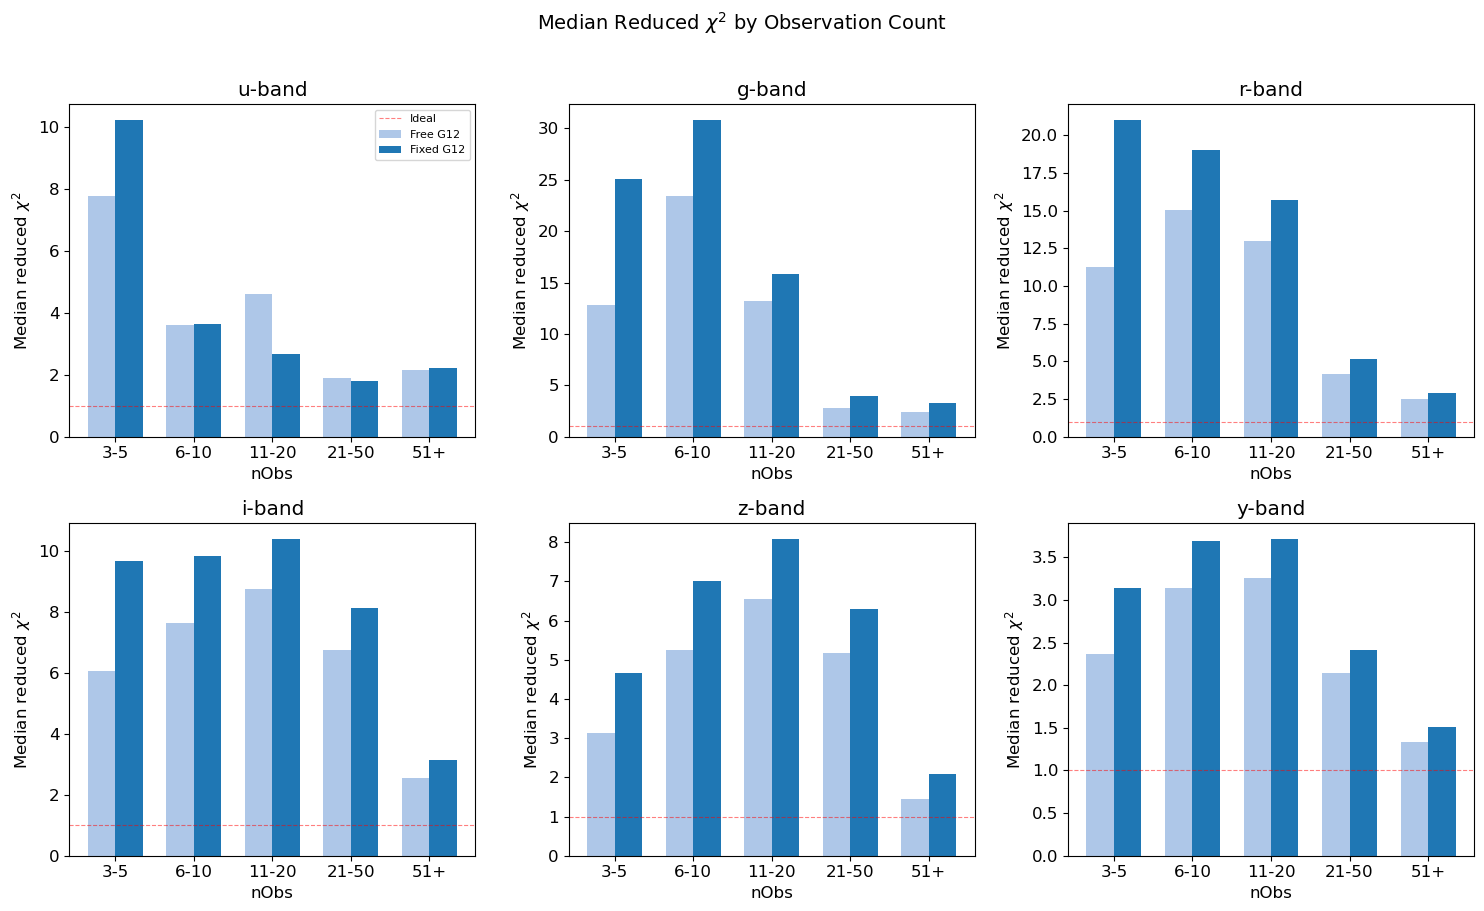

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

nobs_bins = [(3, 5), (6, 10), (11, 20), (21, 50), (51, 1000)]
nobs_labels = ['3-5', '6-10', '11-20', '21-50', '51+']

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    c0 = df0[f'{b}_Chi2']
    c3 = df3[f'{b}_Chi2']
    n0 = df0[f'{b}_nObsUsed'].astype(float)
    n3 = df3[f'{b}_nObsUsed'].astype(float)
    
    med_before = []
    med_after = []
    labels_used = []
    
    for (lo, hi), lbl in zip(nobs_bins, nobs_labels):
        m0 = c0.notna() & (n0 >= lo) & (n0 <= hi) & (n0 > 2)
        m3 = c3.notna() & (n3 >= lo) & (n3 <= hi) & (n3 > 1)
        if m0.sum() > 10:
            rc0 = c0[m0] / (n0[m0] - 2)
            rc3 = c3[m3] / (n3[m3] - 1)
            med_before.append(rc0.median())
            med_after.append(rc3.median())
            labels_used.append(lbl)
    
    x = np.arange(len(labels_used))
    w = 0.35
    ax.bar(x - w/2, med_before, w, label='Free G12', color='#aec7e8')
    ax.bar(x + w/2, med_after, w, label='Fixed G12', color='#1f77b4')
    ax.axhline(1, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Ideal')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_used)
    ax.set_xlabel('nObs')
    ax.set_ylabel('Median reduced $\\chi^2$')
    ax.set_title(f'{b}-band')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Median Reduced $\\chi^2$ by Observation Count', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Detailed reduced chi2 table for r-band
b = 'r'
print(f'Reduced chi2 by nObs bucket ({b}-band)')
print(f'{"nObs":>8} {"N(before)":>10} {"med_rchi2":>10} {"pct<3":>7} {"N(after)":>10} {"med_rchi2":>10} {"pct<3":>7}')
print('-' * 70)

all_bins = [(2, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, 1000)]
all_labels = ['2', '3-5', '6-10', '11-20', '21-50', '51+']

c0 = df0[f'{b}_Chi2']
c3 = df3[f'{b}_Chi2']
n0 = df0[f'{b}_nObsUsed'].astype(float)
n3 = df3[f'{b}_nObsUsed'].astype(float)

for (lo, hi), lbl in zip(all_bins, all_labels):
    m0 = c0.notna() & (n0 >= lo) & (n0 <= hi) & (n0 > 2)
    m3 = c3.notna() & (n3 >= lo) & (n3 <= hi) & (n3 > 1)
    
    if m0.sum() > 0:
        rc0 = c0[m0] / (n0[m0] - 2)
        s0 = f'{m0.sum():>10,} {rc0.median():>10.2f} {(rc0<3).mean()*100:>6.1f}%'
    else:
        s0 = f'{m0.sum():>10,} {"N/A":>10} {"N/A":>7}'
    
    if m3.sum() > 0:
        rc3 = c3[m3] / (n3[m3] - 1)
        s3 = f'{m3.sum():>10,} {rc3.median():>10.2f} {(rc3<3).mean()*100:>6.1f}%'
    else:
        s3 = f'{m3.sum():>10,} {"N/A":>10} {"N/A":>7}'
    
    print(f'{lbl:>8} {s0} {s3}')

Reduced chi2 by nObs bucket (r-band)
    nObs  N(before)  med_rchi2   pct<3   N(after)  med_rchi2   pct<3
----------------------------------------------------------------------
       2          0        N/A     N/A     25,811       8.00   36.9%
     3-5     51,529      11.26   30.1%     69,437      21.02   19.8%
    6-10     76,781      15.06   22.2%     81,784      19.00   18.3%
   11-20     37,148      12.99   22.2%     38,071      15.70   18.5%
   21-50      2,308       4.18   43.0%      2,934       5.18   39.8%
     51+      4,019       2.52   54.4%      4,777       2.88   50.9%


In [9]:
# Chi2 for newly enabled nObsUsed=2 objects (only possible with fixed G12)
print('Chi2 for nObsUsed=2 objects (only in fixed G12, nDof=1):')
print(f'{"Band":>5} {"N":>7} {"Median":>8} {"Mean":>10} {"pct < 3":>9}')
for b in BANDS:
    n3 = df3[f'{b}_nObsUsed'].astype(float)
    c3 = df3[f'{b}_Chi2']
    m3 = c3.notna() & (n3 == 2)
    if m3.sum() > 0:
        print(f'{b:>5} {m3.sum():>7,} {c3[m3].median():>8.2f} {c3[m3].mean():>10.2f} {(c3[m3]<3).mean()*100:>8.1f}%')

Chi2 for nObsUsed=2 objects (only in fixed G12, nDof=1):
 Band       N   Median       Mean   pct < 3
    u  14,859     2.96      71.51     50.3%
    g  49,799     3.25     374.73     48.9%
    r  25,811     8.00     584.61     36.9%
    i  22,327     4.13     434.05     45.4%
    z  24,837     2.00     201.29     57.4%
    y  14,393     1.24     175.06     66.4%


### Chi-squared observations

**1. Reduced chi2 increases modestly with fixed G12**, as expected when fitting fewer parameters. The median reduced chi2 increases by ~20-50% across nObs bins. This is the expected cost of removing one degree of freedom.

**2. Reduced chi2 values are far from 1 in both cases.** Median values range from ~3 (high nObs) to ~20 (low nObs), indicating either underestimated photometric errors, intrinsic variability (rotation curves, shape effects), or model limitations. This is *not* a consequence of fixing G12 — the free fit has similarly elevated reduced chi2.

**3. nObsUsed=2 objects now have meaningful chi2.** With the free fit, these objects had nDof=0 (2 parameters, 2 data points), so chi2 was undefined and the fit often failed. With fixed G12, nDof=1 gives a single degree of freedom to assess fit quality. Median chi2 values of 1-8 across bands suggest these fits are reasonable, with 37-66% having chi2 < 3.

**4. At high nObs (51+), reduced chi2 is close to 3** in both cases, converging toward reasonable values as the model is better constrained by data.

## 6. Newly Gained Fits: Characterization

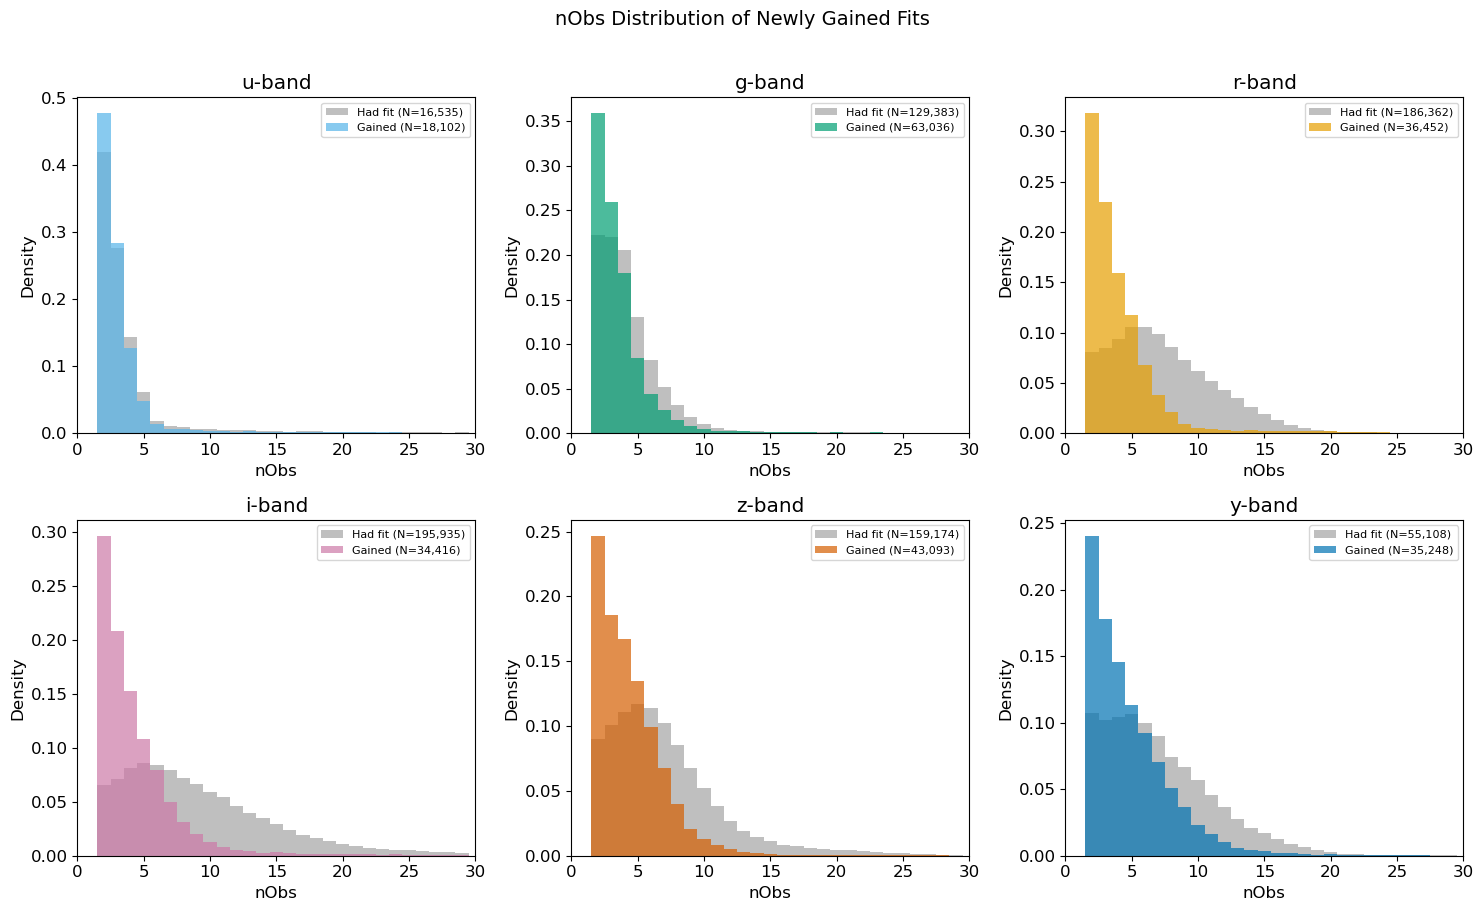

Newly gained fits (failed before, succeeded after):
 Band   Gained  Mean nObs  Median nObs   Min   Max
    u   18,102        6.4            3     2   197
    g   63,036        5.4            3     2   175
    r   36,452        6.4            3     2   241
    i   34,416        6.1            4     2   150
    z   43,093        4.7            4     2    99
    y   35,248        4.9            4     2    66


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    h0_valid = df0[f'{b}_H'].notna()
    h3_valid = df3[f'{b}_H'].notna()
    gained = ~h0_valid & h3_valid
    nobs_gained = df0[f'{b}_nObs'][gained]
    nobs_had = df0[f'{b}_nObs'][h0_valid]
    
    bins = np.arange(0.5, 30.5, 1)
    ax.hist(nobs_had.clip(1, 30), bins=bins, alpha=0.5, color='gray',
            label=f'Had fit (N={h0_valid.sum():,})', density=True)
    ax.hist(nobs_gained.clip(1, 30), bins=bins, alpha=0.7, color=BAND_COLORS[b],
            label=f'Gained (N={gained.sum():,})', density=True)
    ax.set_xlabel('nObs')
    ax.set_ylabel('Density')
    ax.set_title(f'{b}-band')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 30)

fig.suptitle('nObs Distribution of Newly Gained Fits', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Newly gained fits (failed before, succeeded after):')
print(f'{"Band":>5} {"Gained":>8} {"Mean nObs":>10} {"Median nObs":>12} {"Min":>5} {"Max":>5}')
for b in BANDS:
    h0_valid = df0[f'{b}_H'].notna()
    h3_valid = df3[f'{b}_H'].notna()
    gained = ~h0_valid & h3_valid
    nobs = df0[f'{b}_nObs'][gained]
    if gained.sum() > 0:
        print(f'{b:>5} {gained.sum():>8,} {nobs.mean():>10.1f} {nobs.median():>12.0f} {nobs.min():>5} {nobs.max():>5}')

The newly gained fits are concentrated at **low observation counts** (median 3-4 observations), where the 2-parameter fit was failing. However, some objects with surprisingly high nObs (up to ~200) also benefit — these likely had pathological phase angle distributions that made the free G12 fit unstable.

## 7. Verification: G12 and G12Err in Fixed Fit

In [11]:
print('Verification that G12 is correctly fixed and G12Err is NaN:')
print()
for b in BANDS:
    g12 = df3[f'{b}_G12'].dropna()
    g12err = df3[f'{b}_G12Err'].dropna()
    cov = df3[f'{b}_H_{b}_G12_Cov'].dropna()
    unique_vals = g12.unique()
    print(f'{b}: G12 unique values = {unique_vals}, '
          f'G12Err non-NaN count = {len(g12err)}, '
          f'Cov non-NaN count = {len(cov)}')

Verification that G12 is correctly fixed and G12Err is NaN:

u: G12 unique values = [0.5], G12Err non-NaN count = 0, Cov non-NaN count = 0
g: G12 unique values = [0.5], G12Err non-NaN count = 0, Cov non-NaN count = 0
r: G12 unique values = [0.5], G12Err non-NaN count = 0, Cov non-NaN count = 0
i: G12 unique values = [0.5], G12Err non-NaN count = 0, Cov non-NaN count = 0
z: G12 unique values = [0.5], G12Err non-NaN count = 0, Cov non-NaN count = 0
y: G12 unique values = [0.5], G12Err non-NaN count = 0, Cov non-NaN count = 0


## Summary

Fixing G12=0.5 is a clear improvement for this dataset:

1. **Nearly doubles** the number of successful fits in sparse bands (u, y) and gains 18-49% in others, with zero fits lost
2. **Eliminates unphysical G12 values** that were corrupting H estimates — 30-58% of free-fit G12 values were outside the physical range
3. **Produces sensible H error bars** — the free fit's covariance matrix produced absurd errors (mean ~10^7) due to the unconstrained G12; fixed G12 gives errors of 0.02-0.06 mag
4. **H magnitude shifts are small** for well-observed objects (median ~0.03 mag), confirming fixed G12 isn't introducing major bias
5. **Reduced chi2 increases modestly** (~20-50%) as expected for fewer free parameters, but was already far from 1 in both cases due to underestimated photometric errors or intrinsic variability
6. **nObs=2 objects** now have meaningful fits and chi2 values (previously impossible with 0 degrees of freedom)

The universally elevated reduced chi2 values (median ~3-20 depending on band and nObs) in *both* runs suggest that the dominant issue is not the choice of G12 but rather the photometric error model — measurement uncertainties may be underestimated, or intrinsic brightness variations (rotation curves) contribute scatter that the HG12 model cannot capture.